# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Vito Gunawan
- **Email:** vitogunawan88@gmail.com
- **ID Dicoding:** vito_gunawan


## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Apa 10 kategori produk yang paling banyak terjual dan 10 kategori produk yang paling sedikit terjual berdasarkan jumlah pesanan?
- **Pertanyaan 2:** Bagaimana tren pendapatan penjualan bulanan dan jumlah pesanan yang terjadi sepanjang tahun 2017?


## Import Semua Packages/Library yang Digunakan

In [2]:
# Install library yang dibutuhkan sesuai dengan requirements.txt
!pip install pandas==2.2.1
!pip install matplotlib==3.7.3
!pip install seaborn==0.13.2
!pip install streamlit==1.32.2
!pip install numpy==1.26.4

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Import library yang akan digunakan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt
import warnings

# Mengabaikan pesan warning
warnings.filterwarnings('ignore')


## Data Wrangling

### Gathering Data
Memuat dataset dari E-Commerce Public Dataset.

#### Load df ...

In [8]:
base_dir = "/content/drive/MyDrive/submision/Data/"
orders_df = pd.read_csv(base_dir + "orders_dataset.csv")
order_items_df = pd.read_csv(base_dir + "order_items_dataset.csv")
products_df = pd.read_csv(base_dir + "products_dataset.csv")
category_trans_df = pd.read_csv(base_dir + "product_category_name_translation.csv")
customers_df = pd.read_csv(base_dir + "customers_dataset.csv")
order_payments_df = pd.read_csv(base_dir + "order_payments_dataset.csv")
print("Data loaded successfully.")

Data loaded successfully.


**Insight:**
- Terdapat beberapa dataset yang saling berelasi, namun yang akan digunakan utamanya adalah orders, order_items, products, dan category_translation.
- Dataset customers dan payments juga dimuat untuk analisis lanjutan (RFM).

### Assessing Data

#### Mengidentifikasi Masalah pada Data (Missing Values & Tipe Data)

In [9]:
print("Info Orders:")
print(orders_df.info())
print("\nMissing values pada Orders:")
print(orders_df.isna().sum())

print("\nInfo Products:")
print(products_df.info())
print("\nMissing values pada Products:")
print(products_df.isna().sum())

print("\nDuplikasi Data:")
print("Orders:", orders_df.duplicated().sum())
print("Order Items:", order_items_df.duplicated().sum())
print("Products:", products_df.duplicated().sum())

Info Orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Missing values pada Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_d

**Steps to Take:**
- Mengubah tipe data kolom tanggal pada `orders_df` menjadi datetime.
- Menangani missing values pada nama kategori produk jika ada.

**Insight:**
- Pada `orders_df`, kolom `order_purchase_timestamp` dan kolom tanggal lainnya masih bertipe object.
- Terdapat beberapa missing values pada `orders_df` untuk pesanan yang belum terkirim.
- Tidak ada masalah duplikasi data yang signifikan.

### Cleaning Data

#### Memperbaiki Tipe Data dan Missing Values

In [10]:
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
                    "order_delivered_customer_date", "order_estimated_delivery_date"]
for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Menggabungkan product dengan translation
products_df = pd.merge(products_df, category_trans_df, on="product_category_name", how="left")
products_df['product_category_name_english'] = products_df['product_category_name_english'].fillna(products_df['product_category_name'])

print("Tipe data setelah dibersihkan:")
print(orders_df.dtypes)

Tipe data setelah dibersihkan:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


**Insight:**
- Kolom tanggal telah diubah menjadi tipe `datetime64`.
- Nama kategori produk telah digabungkan dengan terjemahan bahasa Inggris untuk mempermudah pemahaman.

## Exploratory Data Analysis (EDA)

### Eksplorasi Data Produk dan Pesanan

In [11]:
# Menggabungkan data untuk melihat produk dan pesanannya
item_prod_df = pd.merge(order_items_df, products_df, on="product_id", how="left")
category_counts = item_prod_df['product_category_name_english'].value_counts().reset_index()
category_counts.columns = ['product_category', 'order_count']

# Eksplorasi pendapatan
orders_with_items = pd.merge(orders_df, order_items_df, on="order_id", how="left")
orders_with_items['month'] = orders_with_items['order_purchase_timestamp'].dt.to_period('M')

display(category_counts.head())


,product_category,order_count
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827


**Insight:**
- Kategori bed_bath_table, health_beauty, dan sports_leisure merupakan beberapa kategori dengan pesanan terbanyak.
- Data sudah digabungkan dan siap untuk divisualisasikan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang paling banyak dan paling sedikit terjual?

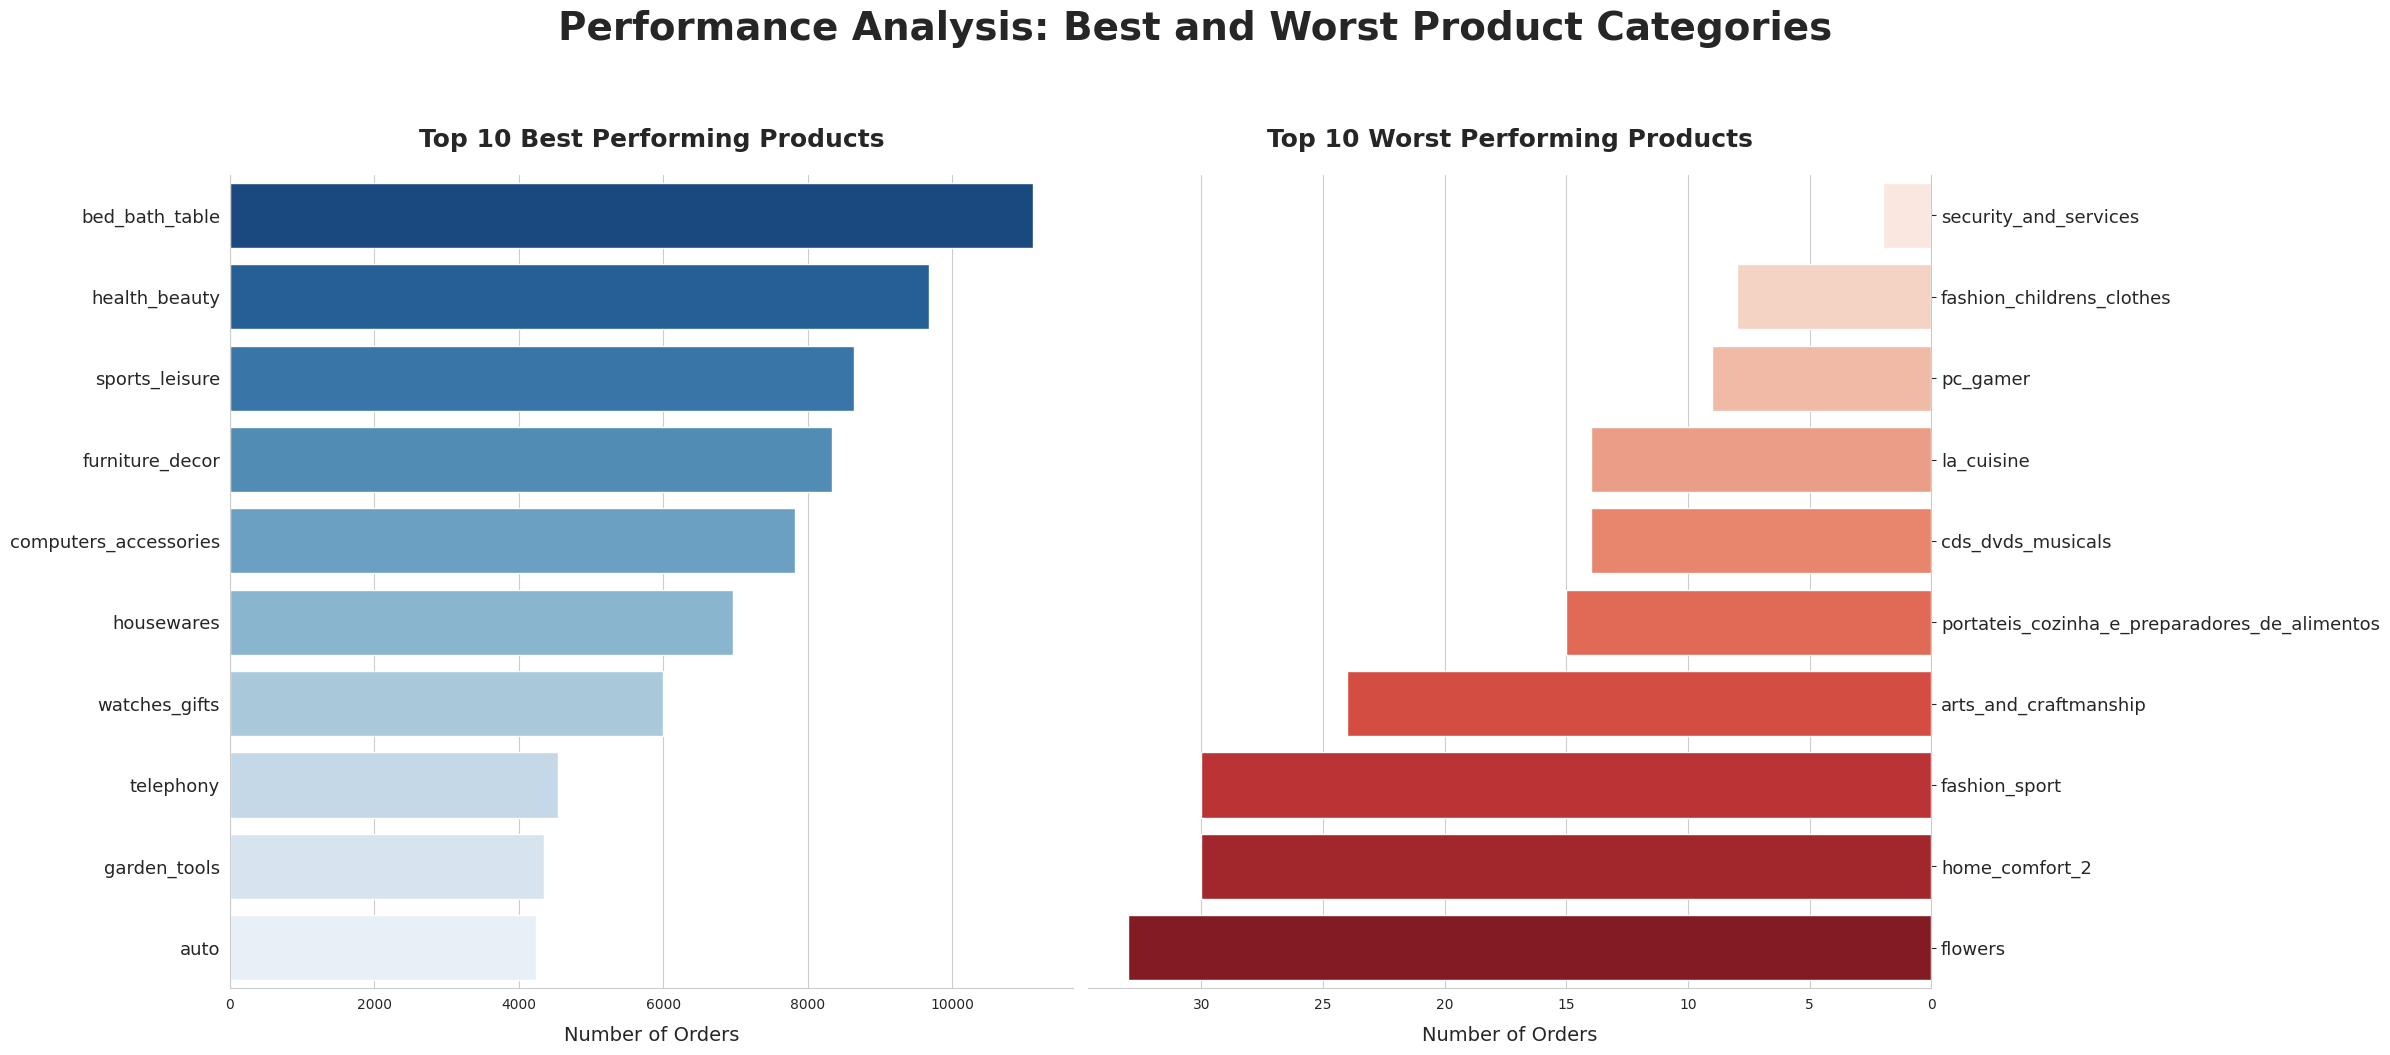

In [15]:
# Set style agar lebih bersih
sns.set_style("whitegrid")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

top_colors = sns.color_palette("Blues_r", n_colors=10)
bottom_colors = sns.color_palette("Reds", n_colors=10)

# --- Plot Top 10 ---
sns.barplot(
    x="order_count",
    y="product_category",
    data=top_10,
    palette=top_colors,
    ax=ax[0],
    hue="product_category",
    legend=False
)
ax[0].set_ylabel(None)
ax[0].set_xlabel('Number of Orders', fontsize=14, labelpad=10)
ax[0].set_title("Top 10 Best Performing Products", loc="center", fontsize=18, fontweight='bold', pad=20)
ax[0].tick_params(axis='y', labelsize=13)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)


sns.barplot(
    x="order_count",
    y="product_category",
    data=bottom_10,
    palette=bottom_colors,
    ax=ax[1],
    hue="product_category",
    legend=False
)
ax[1].set_ylabel(None)
ax[1].set_xlabel('Number of Orders', fontsize=14, labelpad=10)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Top 10 Worst Performing Products", loc="center", fontsize=18, fontweight='bold', pad=20)
ax[1].tick_params(axis='y', labelsize=13)
ax[1].spines['top'].set_visible(False)
ax[1].spines['left'].set_visible(False)

plt.suptitle("Performance Analysis: Best and Worst Product Categories", fontsize=28, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana tren pendapatan penjualan bulanan sepanjang tahun 2017?

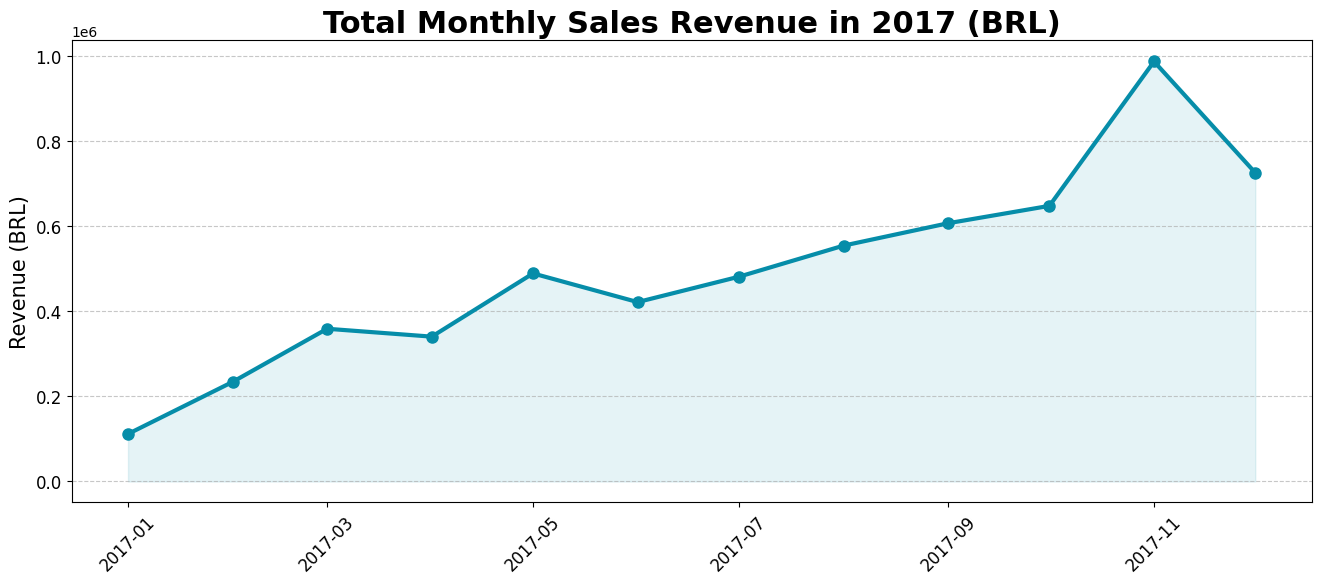

In [13]:
orders_2017 = orders_with_items[(orders_with_items['order_purchase_timestamp'].dt.year == 2017) & (orders_with_items['order_status'] == 'delivered')]
monthly_stats = orders_2017.groupby('month').agg(
    revenue=('price', 'sum')
).reset_index()
monthly_stats['month'] = monthly_stats['month'].dt.to_timestamp()

plt.figure(figsize=(16, 6))
plt.plot(monthly_stats['month'], monthly_stats['revenue'], marker='o', linewidth=3, color="#068DA9", markersize=8)
plt.title("Total Monthly Sales Revenue in 2017 (BRL)", loc="center", fontsize=22, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.ylabel("Revenue (BRL)", fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.fill_between(monthly_stats['month'], monthly_stats['revenue'], color="#068DA9", alpha=0.1)
plt.show()

**Insight:**
- Terdapat lonjakan pendapatan yang sangat signifikan pada bulan November 2017. Ini kemungkinan besar disebabkan oleh event Black Friday.
- Tren penjualan secara umum menunjukkan peningkatan dari awal tahun hingga puncaknya di bulan November.

## Analisis Lanjutan (RFM Analysis)

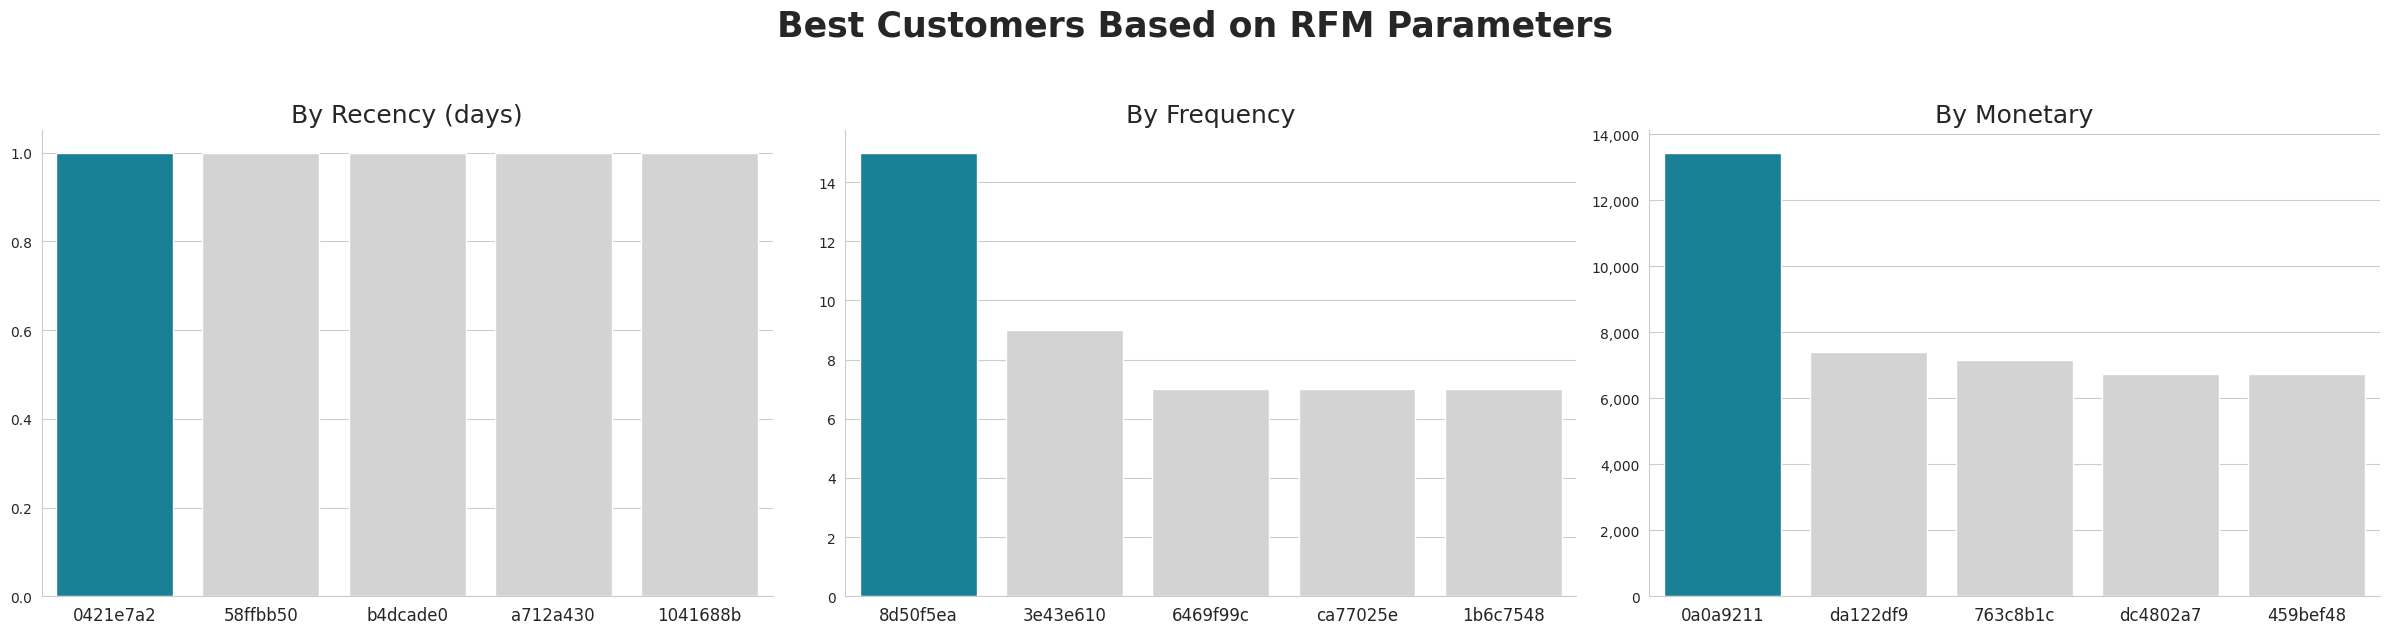

In [18]:
# Menyiapkan Data RFM
rfm_df = orders_with_items[orders_with_items['order_status'] == 'delivered'].copy()
rfm_df = pd.merge(rfm_df, customers_df, on="customer_id")
recent_date = rfm_df['order_purchase_timestamp'].max()

rfm = rfm_df.groupby('customer_unique_id').agg({
       'order_purchase_timestamp': lambda x: (recent_date - x.max()).days + 1,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# 2. Membuat kolom ID pendek agar sumbu X rapi
rfm['short_id'] = rfm['customer_id'].str[:8]

# 3. Visualisasi RFM Top 5
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(24, 6))

# Warna highlight untuk peringkat 1, abu-abu untuk sisanya
colors = ["#068DA9", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# --- By Recency ---
sns.barplot(y="recency", x="short_id", data=rfm.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis='x', labelsize=12)
ax[0].set_xlabel('')
ax[0].set_ylabel('')

# --- By Frequency ---
sns.barplot(y="frequency", x="short_id", data=rfm.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=12)
ax[1].set_xlabel('')
ax[1].set_ylabel('')

# --- By Monetary ---
sns.barplot(y="monetary", x="short_id", data=rfm.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=12)
ax[2].set_xlabel('')
ax[2].set_ylabel('')
# Memformat sumbu Y menjadi format angka ribuan yang mudah dibaca
ax[2].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Membersihkan border atas dan kanan agar lebih estetik
for i in range(3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

plt.suptitle("Best Customers Based on RFM Parameters", fontsize=25, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Kategori produk yang paling laris dan menghasilkan pesanan tertinggi adalah `bed_bath_table`, disusul oleh `health_beauty` dan `sports_leisure`. Sebaliknya, produk yang paling sedikit terjual meliputi kategori `security_and_services` dan `fashion_childrens_clothes`.
- **Conclusion Pertanyaan 2:** Tren pendapatan pada tahun 2017 secara keseluruhan mengalami peningkatan positif, dengan lonjakan tertinggi terjadi di bulan November, yang mana sangat berhubungan dengan adanya kampanye musim liburan seperti Black Friday.

**Rekomendasi Action Item:**
- Memberikan promosi bundle atau diskon khusus untuk kategori produk terlaris (`bed_bath_table`, `health_beauty`) untuk semakin mendongkrak pendapatan.
- Melakukan evaluasi mendalam pada kategori dengan penjualan terendah; pertimbangkan pengurangan stok atau memberikan clearance sale.
- Mengalokasikan anggaran marketing yang lebih besar menjelang bulan November untuk memaksimalkan potensi lonjakan penjualan musim liburan.